# Dry Bulk Market Diagnostic Framework

This notebook supports the research note in this repository. It builds simple market indicators for BDI, iron ore, and Brent crude oil, then uses them to describe the current dry bulk market regime.

The notebook is meant to be transparent and easy to explain. It is not a production forecasting model and it is not a trading signal.


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create output folders if they do not already exist
Path("figures").mkdir(exist_ok=True)
Path("data").mkdir(exist_ok=True)


## Step 1: Read and clean the data

The project uses three public market series:

- Baltic Dry Index (BDI)
- Brent crude oil
- Iron ore futures

The data sources have slightly different formats, so I first clean the dates and price columns, then merge the series by date.

The raw CSV files were used locally and are not uploaded to GitHub. The `data/README.md` file documents the data sources and expected file names.


In [2]:
# File paths
bdi_path = "Baltic Dry Index Historical Data.csv"
brent_path = "DCOILBRENTEU.csv"
iron_path = "Iron ore fines 62% Fe CFR Futures Historical Data.csv"


def clean_price(x):
    """Convert price strings such as '2,981' into numeric values."""
    if pd.isna(x):
        return np.nan
    return pd.to_numeric(str(x).replace(",", "").replace("%", ""), errors="coerce")


# Read raw files
bdi = pd.read_csv(bdi_path)
brent = pd.read_csv(brent_path)
iron = pd.read_csv(iron_path)

# Clean BDI
bdi["Date"] = pd.to_datetime(bdi["Date"], format="%m/%d/%Y")
bdi["BDI"] = bdi["Price"].apply(clean_price)
bdi = bdi[["Date", "BDI"]]

# Clean Brent
brent["Date"] = pd.to_datetime(brent["observation_date"])
brent["Brent"] = pd.to_numeric(brent["DCOILBRENTEU"], errors="coerce")
brent = brent[["Date", "Brent"]]

# Clean Iron Ore
iron["Date"] = pd.to_datetime(iron["Date"], format="%m/%d/%Y")
iron["IronOre"] = iron["Price"].apply(clean_price)
iron = iron[["Date", "IronOre"]]

# Merge the series by date
# I use an outer join because the markets do not always share the same trading calendar.
df = (
    bdi
    .merge(brent, on="Date", how="outer")
    .merge(iron, on="Date", how="outer")
    .sort_values("Date")
    .set_index("Date")
)

# Forward-fill missing observations caused by market holidays.
# This is a practical choice for a first diagnostic version, but it is also a limitation.
df = df.ffill().dropna()

# Daily returns
df["BDI_ret"] = df["BDI"].pct_change()
df["Brent_ret"] = df["Brent"].pct_change()
df["IronOre_ret"] = df["IronOre"].pct_change()

df = df.dropna()

# Save the cleaned dataset locally for reference.
# I do not upload raw market data to GitHub.
df.to_csv("data/dry_bulk_dataset_clean.csv")

df.head()


,BDI,Brent,IronOre,BDI_ret,Brent_ret,IronOre_ret
Date,,,,,,
2025-06-03,1430.0,67.48,95.30,0.005626,0.013974,-0.006774
2025-06-04,1489.0,66.69,96.26,0.041259,-0.011707,0.010073
2025-06-05,1626.0,67.14,95.70,0.092008,0.006748,-0.005818
2025-06-06,1633.0,68.02,96.18,0.004305,0.013107,0.005016
2025-06-09,1691.0,68.73,95.62,0.035517,0.010438,-0.005822


## Step 2: Build market indicators

I use simple indicators that are easy to interpret:

- BDI moving averages for trend
- BDI volatility and drawdown for risk
- Iron ore momentum as a demand-side proxy
- Brent momentum as an energy-cost proxy


In [3]:
# Trend indicators
df["BDI_MA20"] = df["BDI"].rolling(20).mean()
df["BDI_MA60"] = df["BDI"].rolling(60).mean()

# Risk indicators
df["BDI_vol20"] = df["BDI_ret"].rolling(20).std() * np.sqrt(252)
df["BDI_running_max"] = df["BDI"].cummax()
df["BDI_drawdown"] = df["BDI"] / df["BDI_running_max"] - 1

# Demand and cost proxy momentum
df["IronOre_momentum20"] = df["IronOre"].pct_change(20)
df["Brent_momentum20"] = df["Brent"].pct_change(20)

# Drop rows where rolling indicators are not available yet
df_model = df.dropna().copy()

df_model.tail()


,BDI,Brent,IronOre,BDI_ret,Brent_ret,IronOre_ret,BDI_MA20,BDI_MA60,BDI_vol20,BDI_running_max,BDI_drawdown,IronOre_momentum20,Brent_momentum20
Date,,,,,,,,,,,,,
2026-06-02,3205.0,98.29,105.13,-0.005276,0.0,0.000952,3089.25,2555.216667,0.336131,3226.0,-0.006510,-0.031774,-0.141647
2026-06-03,3124.0,98.29,103.71,-0.025273,0.0,-0.013507,3095.90,2575.183333,0.298508,3226.0,-0.031618,-0.064496,-0.052170
2026-06-04,3037.0,98.29,101.96,-0.027849,0.0,-0.016874,3096.05,2592.933333,0.313202,3226.0,-0.058586,-0.081027,-0.034669
2026-06-05,2981.0,98.29,102.00,-0.018439,0.0,0.000392,3096.20,2608.816667,0.313188,3226.0,-0.075945,-0.080501,-0.050155
2026-06-08,2981.0,98.29,101.05,0.000000,0.0,-0.009314,3095.20,2624.533333,0.311936,3226.0,-0.075945,-0.093071,-0.073697


## Step 3: Define a simple market regime rule

The regime is not a prediction. It is only a simple way to summarize the current market condition.

The logic is:

1. If volatility or drawdown is high, I classify the market as **Risk Watch**.
2. If BDI is above both moving averages and iron ore momentum is positive, I classify it as **Constructive**.
3. If BDI is below both moving averages, I classify it as **Caution**.
4. Otherwise, the signals are mixed, so I classify it as **Neutral**.

I use this rule because it is transparent and easy to explain. I do not optimize the thresholds, because this project is a diagnostic framework rather than a predictive model.


In [4]:
# I use the 75th percentile of recent volatility as a simple "high volatility" level.
# This is only a rule of thumb, not an optimized threshold.
high_volatility_level = df_model["BDI_vol20"].quantile(0.75)


def classify_regime(row):
    """
    Simple rule-based market regime classification.

    This is not a forecasting model.
    It is only used to summarize whether the current market looks supportive,
    weak, risky, or mixed.
    """

    # 1. Risk comes first: high volatility or large drawdown
    if row["BDI_vol20"] > high_volatility_level or row["BDI_drawdown"] < -0.15:
        return "Risk Watch"

    # 2. Constructive: trend is positive and demand proxy is supportive
    if (
        row["BDI"] > row["BDI_MA20"]
        and row["BDI"] > row["BDI_MA60"]
        and row["IronOre_momentum20"] > 0
        and row["Brent_momentum20"] < 0.05
    ):
        return "Constructive"

    # 3. Caution: BDI is below both short-term and medium-term trend
    if row["BDI"] < row["BDI_MA20"] and row["BDI"] < row["BDI_MA60"]:
        return "Caution"

    # 4. Neutral: mixed signals
    return "Neutral"


df_model["Market_Regime"] = df_model.apply(classify_regime, axis=1)

print(df_model["Market_Regime"].value_counts())

df_model.tail(10)[[
    "BDI",
    "BDI_MA20",
    "BDI_MA60",
    "BDI_vol20",
    "BDI_drawdown",
    "IronOre_momentum20",
    "Brent_momentum20",
    "Market_Regime"
]]


Market_Regime
Risk Watch      108
Constructive     55
Neutral          33
Caution          10
Name: count, dtype: int64


,BDI,BDI_MA20,BDI_MA60,BDI_vol20,BDI_drawdown,IronOre_momentum20,Brent_momentum20,Market_Regime
Date,,,,,,,,
2026-05-26,3085.0,2971.60,2461.300000,0.340062,-0.034429,0.019978,-0.126424,Constructive
2026-05-27,3124.0,2994.30,2476.150000,0.338451,-0.022222,0.019785,-0.217864,Constructive
2026-05-28,3226.0,3021.30,2494.283333,0.349308,0.000000,0.017354,-0.231568,Constructive
2026-05-29,3224.0,3046.00,2514.516667,0.350032,-0.000620,0.008900,-0.214612,Constructive
2026-06-01,3222.0,3070.60,2533.783333,0.350241,-0.001240,-0.029028,-0.168865,Neutral
2026-06-02,3205.0,3089.25,2555.216667,0.336131,-0.006510,-0.031774,-0.141647,Neutral
2026-06-03,3124.0,3095.90,2575.183333,0.298508,-0.031618,-0.064496,-0.052170,Neutral
2026-06-04,3037.0,3096.05,2592.933333,0.313202,-0.058586,-0.081027,-0.034669,Neutral
2026-06-05,2981.0,3096.20,2608.816667,0.313188,-0.075945,-0.080501,-0.050155,Neutral


## Step 4: Plot BDI trend

This chart compares BDI with its 20-day and 60-day moving averages. I use it to see whether the market is above or below short-term and medium-term trend.


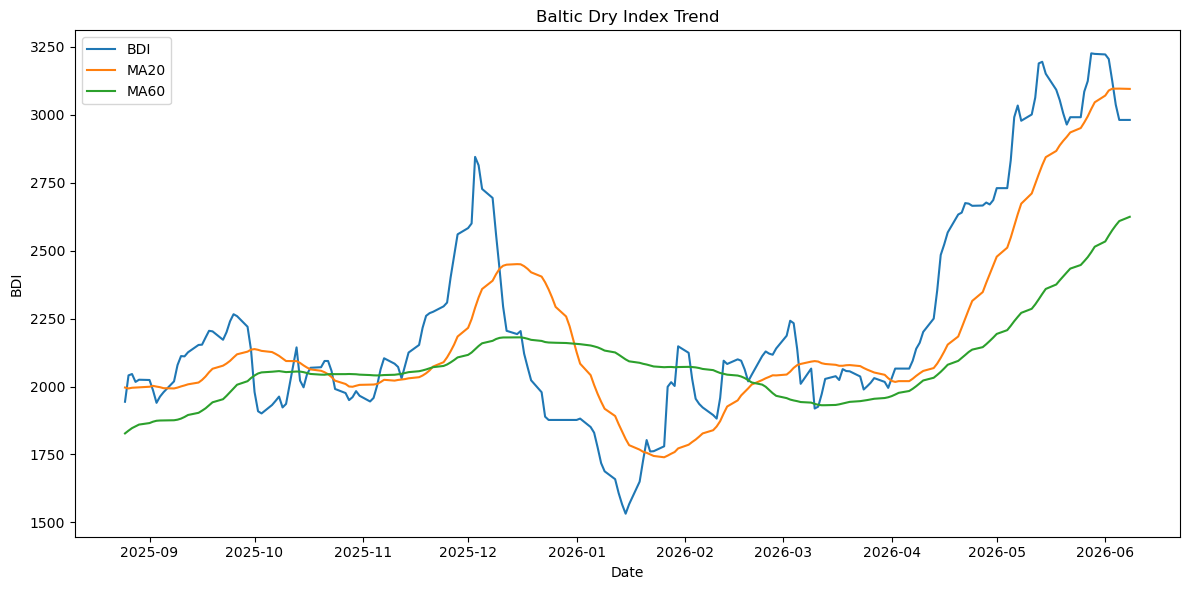

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df_model.index, df_model["BDI"], label="BDI")
plt.plot(df_model.index, df_model["BDI_MA20"], label="MA20")
plt.plot(df_model.index, df_model["BDI_MA60"], label="MA60")
plt.title("Baltic Dry Index Trend")
plt.xlabel("Date")
plt.ylabel("BDI")
plt.legend()
plt.tight_layout()
plt.savefig("figures/figure_1_bdi_trend.png", dpi=300)
plt.show()


## Step 5: Plot volatility

This chart shows the 20-day annualized volatility of BDI returns. I use it as a simple risk indicator.


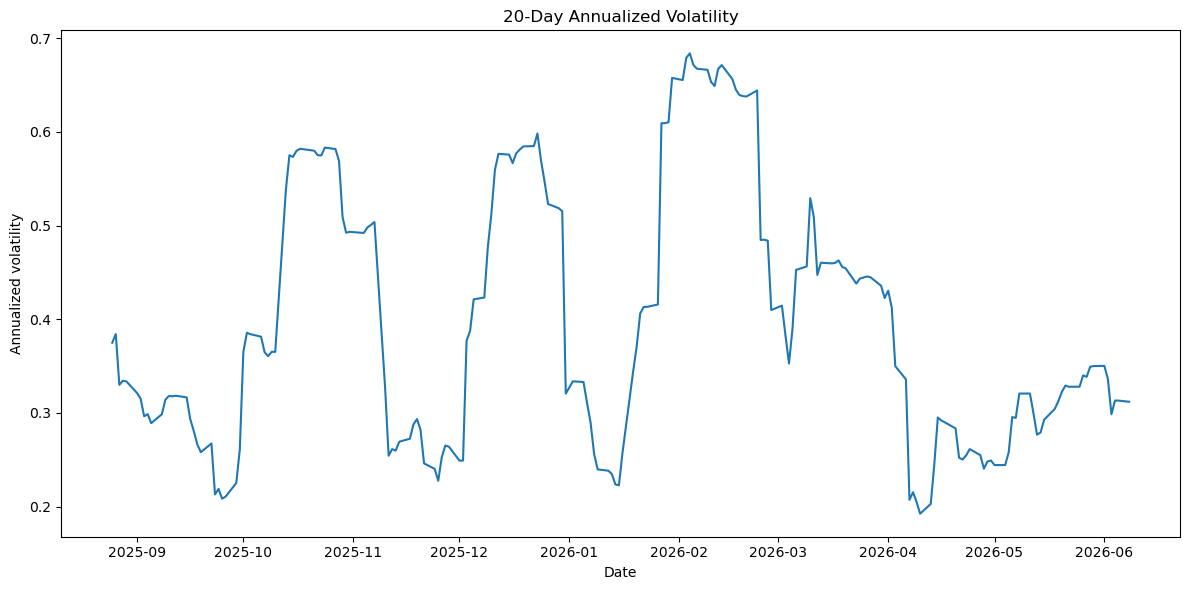

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(df_model.index, df_model["BDI_vol20"])
plt.title("20-Day Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized volatility")
plt.tight_layout()
plt.savefig("figures/figure_2_bdi_volatility.png", dpi=300)
plt.show()


## Step 6: Plot drawdown

Drawdown measures how far BDI has fallen from its previous peak. This gives a simple risk view of the market.


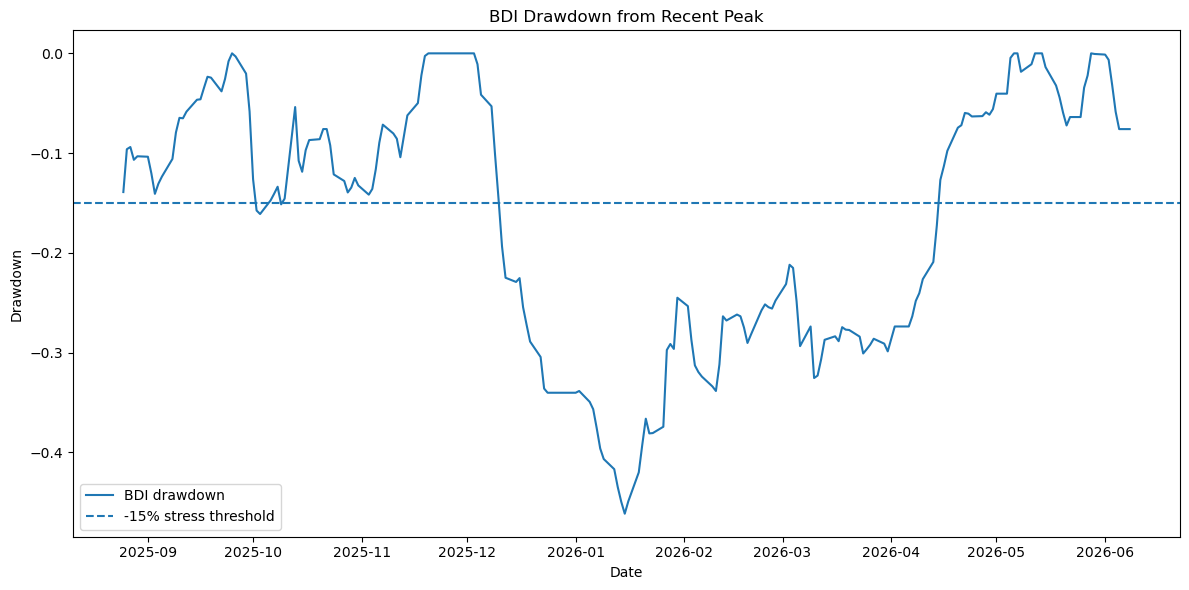

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(df_model.index, df_model["BDI_drawdown"], label="BDI drawdown")
plt.axhline(y=-0.15, linestyle="--", label="-15% stress threshold")
plt.title("BDI Drawdown from Recent Peak")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.tight_layout()
plt.savefig("figures/figure_3_bdi_drawdown.png", dpi=300)
plt.show()


## Step 7: Compare iron ore momentum and BDI returns

This scatter plot tests the first simple hypothesis: whether iron ore momentum helps explain short-term BDI returns.


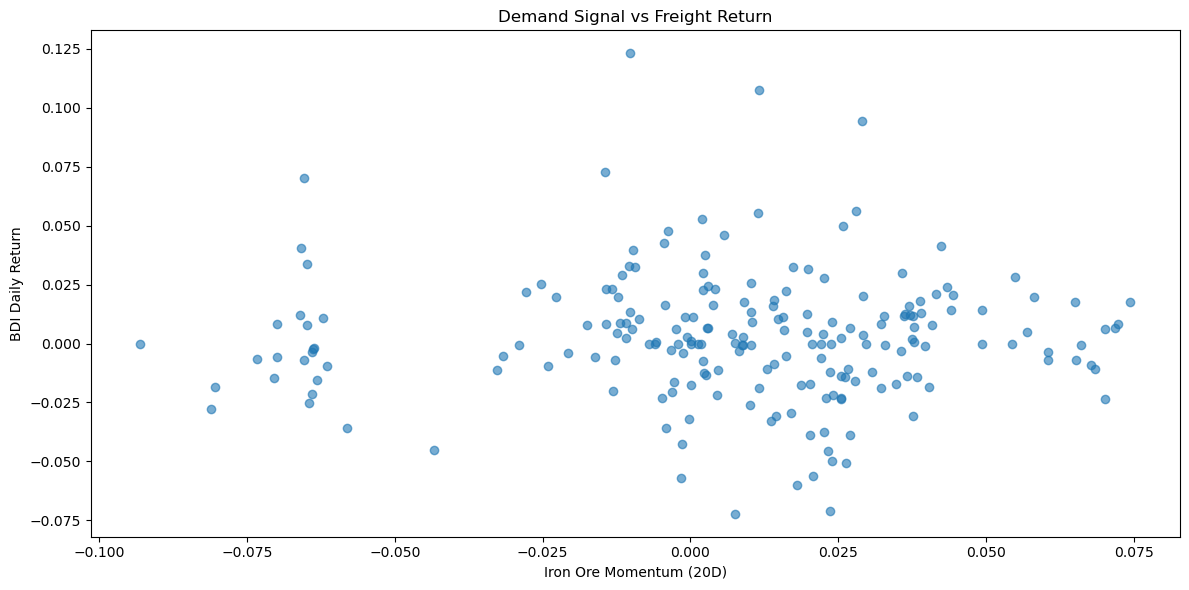

In [8]:
plt.figure(figsize=(12, 6))
plt.scatter(df_model["IronOre_momentum20"], df_model["BDI_ret"], alpha=0.6)
plt.xlabel("Iron Ore Momentum (20D)")
plt.ylabel("BDI Daily Return")
plt.title("Demand Signal vs Freight Return")
plt.tight_layout()
plt.savefig("figures/figure_4_iron_ore_momentum_vs_bdi_return.png", dpi=300)
plt.show()


## Step 8: Current market diagnosis

This table summarizes the latest available market state.


In [9]:
latest = df_model.iloc[-1]

summary = pd.DataFrame({
    "Metric": [
        "BDI",
        "20-day moving average",
        "60-day moving average",
        "20-day annualized volatility",
        "Drawdown from recent high",
        "Iron ore 20-day momentum",
        "Brent 20-day momentum",
        "Market regime"
    ],
    "Value": [
        round(latest["BDI"], 2),
        round(latest["BDI_MA20"], 2),
        round(latest["BDI_MA60"], 2),
        f"{latest['BDI_vol20']:.2%}",
        f"{latest['BDI_drawdown']:.2%}",
        f"{latest['IronOre_momentum20']:.2%}",
        f"{latest['Brent_momentum20']:.2%}",
        latest["Market_Regime"]
    ]
})

summary


,Metric,Value
0,BDI,2981.0
1,20-day moving average,3095.2
2,60-day moving average,2624.53
3,20-day annualized volatility,31.19%
4,Drawdown from recent high,-7.59%
5,Iron ore 20-day momentum,-9.31%
6,Brent 20-day momentum,-7.37%
7,Market regime,Neutral


## Step 9: Correlation check

The correlation table is a simple check of whether the demand-side proxy has a strong relationship with BDI returns in this sample.


In [10]:
corr_table = df_model[[
    "BDI_ret",
    "IronOre_ret",
    "Brent_ret",
    "IronOre_momentum20",
    "Brent_momentum20"
]].corr()

corr_table


,BDI_ret,IronOre_ret,Brent_ret,IronOre_momentum20,Brent_momentum20
BDI_ret,1.000000,0.140950,-0.033625,-0.002000,-0.013311
IronOre_ret,0.140950,1.000000,0.044792,0.285387,0.121325
Brent_ret,-0.033625,0.044792,1.000000,0.036767,0.317540
IronOre_momentum20,-0.002000,0.285387,0.036767,1.000000,0.379244
Brent_momentum20,-0.013311,0.121325,0.317540,0.379244,1.000000


## Important limitation

The sample is short and covers approximately one recent year. The regime classification is therefore only a short-term diagnostic tool.

This notebook does not build a validated forecasting model and should not be interpreted as a trading signal. A longer sample and more variables, especially supply-side variables, would be needed before making stronger conclusions.
